In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import preprocessing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv(r"C:\Users\ADITYA\Downloads\car-mpg.csv")

In [3]:
data

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_type,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,0,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,0,ford torino
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,1,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,1,ford ranger


In [4]:
data.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_type,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,0,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,0,ford torino


In [5]:
data = data.drop(['car_name'], axis = 1)
data['origin'] = data['origin'].replace({1: 'america', 2: 'europe', 3: 'asia'})
data = pd.get_dummies(data,columns = ['origin'])
data = data.replace('?', np.nan)


In [6]:
X = data.drop(['mpg'], axis = 1)
y = data[['mpg']]

In [7]:
X

,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,8,307.0,130,3504,12.0,70,0,True,False,False
1,8,350.0,165,3693,11.5,70,0,True,False,False
2,8,318.0,150,3436,11.0,70,0,True,False,False
3,8,304.0,150,3433,12.0,70,0,True,False,False
4,8,302.0,140,3449,10.5,70,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...
393,4,140.0,86,2790,15.6,82,1,True,False,False
394,4,97.0,52,2130,24.6,82,1,False,False,True
395,4,135.0,84,2295,11.6,82,1,True,False,False
396,4,120.0,79,2625,18.6,82,1,True,False,False


In [8]:
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


In [9]:
X_s = preprocessing.scale(X)
X_s = pd.DataFrame(X_s, columns = X.columns) 

y_s = preprocessing.scale(y)
y_s = pd.DataFrame(y_s, columns = y.columns)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_s, y_s, test_size = 0.30, random_state = 1)
X_train.shape

(278, 10)

In [11]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

In [12]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

for idx, col_name in enumerate(X_train.columns):
    print('The coefficient for {} is {}'.format(col_name, regression_model.coef_[0][idx]))
    
intercept = regression_model.intercept_[0]
print('The intercept is {}'.format(intercept))

The coefficient for cyl is 0.3103410997079565
The coefficient for disp is 0.3204779849884451
The coefficient for hp is -0.25656465602875556
The coefficient for wt is -0.6689748456780273
The coefficient for acc is 0.006310757824291361
The coefficient for yr is 0.3733609559016766
The coefficient for car_type is 0.3932127763086904
The coefficient for origin_america is -0.0708021175214625
The coefficient for origin_asia is 0.04719095158129853
The coefficient for origin_europe is 0.04056183098702126
The intercept is 0.01738780919033585


In [13]:
ridge_model = Ridge(alpha = 0.3)
ridge_model.fit(X_train, y_train)

print('Ridge model coef: {}'.format(ridge_model.coef_))

Ridge model coef: [[ 0.30567404  0.30910607 -0.25576453 -0.65937013  0.00470074  0.37229859
   0.38888425 -0.0702847   0.04706741  0.04003354]]


In [14]:
lasso_model = Lasso(alpha = 0.1)
lasso_model.fit(X_train, y_train)

print('Lasso model coef: {}'.format(lasso_model.coef_))

Lasso model coef: [-0.         -0.         -0.03173269 -0.49574218  0.          0.28082297
  0.14447175 -0.00665008  0.          0.        ]


In [15]:
print(regression_model.score(X_train, y_train))
print(regression_model.score(X_test, y_test))

print('****************************')

print(ridge_model.score(X_train, y_train))
print(ridge_model.score(X_test, y_test))

print('***************************')

print(lasso_model.score(X_train, y_train))
print(lasso_model.score(X_test, y_test))

0.8359398616204183
0.849495976676595
****************************
0.8359251367276268
0.8499982664925672
***************************
0.7960642072686119
0.8348380060373659


In [16]:
data_train_test = pd.concat([X_train, y_train], axis =1)
data_train_test.head()

,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe,mpg
350,-0.856321,-0.849116,-1.078751,-0.893172,-0.242570,1.351199,0.941412,0.773559,-0.497643,-0.461968,1.432898
59,-0.856321,-0.925936,-1.312870,-0.847061,2.879909,-1.085858,0.941412,-1.292726,-0.497643,2.164651,-0.065919
120,-0.856321,-0.695475,0.195895,-0.121101,-0.024722,-0.815074,0.941412,-1.292726,-0.497643,2.164651,-0.578335
12,1.498191,1.983643,1.184397,0.934732,-2.203196,-1.627426,-1.062235,0.773559,-0.497643,-0.461968,-1.090751
349,-0.856321,-0.983552,-0.948685,-1.165111,0.156817,1.351199,0.941412,-1.292726,2.009471,-0.461968,1.356035


In [17]:
import statsmodels.formula.api as smf
ols1 = smf.ols(formula = 'mpg ~ cyl+disp+hp+wt+acc+yr+car_type+origin_america+origin_europe+origin_asia', data = data_train_test).fit()
ols1.params

Intercept         0.017388
cyl               0.310341
disp              0.320478
hp               -0.256565
wt               -0.668975
acc               0.006311
yr                0.373361
car_type          0.393213
origin_america   -0.070802
origin_europe     0.040562
origin_asia       0.047191
dtype: float64

In [18]:
print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     148.9
Date:                Fri, 26 Sep 2025   Prob (F-statistic):           7.57e-98
Time:                        16:58:31   Log-Likelihood:                -142.96
No. Observations:                 273   AIC:                             305.9
Df Residuals:                     263   BIC:                             342.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0174      0.025      0.

In [19]:
mse = np.mean((regression_model.predict(X_test)-y_test)**2)

import math
rmse = math.sqrt(mse)
print('Root Mean Squared Error: {}'.format(rmse))

Root Mean Squared Error: 0.3781541991633671


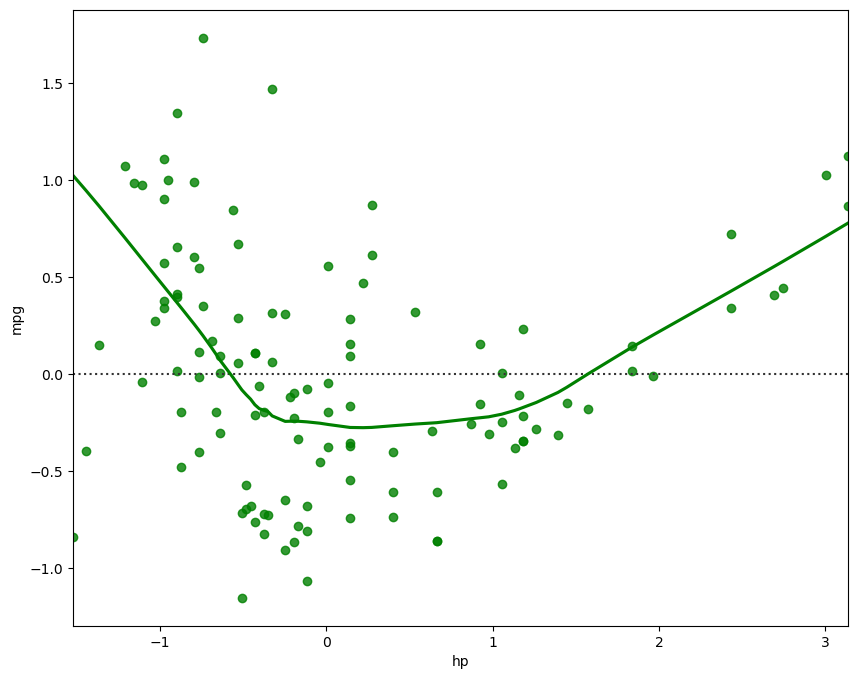

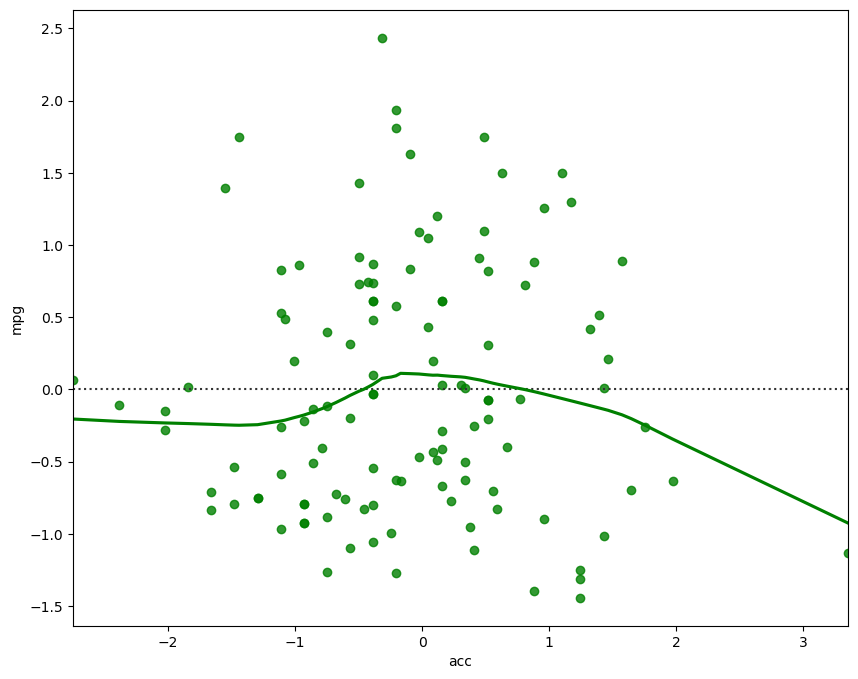

In [20]:
fig = plt.figure(figsize=(10,8))
sns.residplot(x=X_test['hp'], y= y_test['mpg'], color='green', lowess = True)

fig = plt.figure(figsize=(10,8))
sns.residplot(x=X_test['acc'], y= y_test['mpg'], color='green', lowess=True)

plt.show()

In [21]:
y_pred = regression_model.predict(X_test)
plt.scatter(y_test['mpg'], y_pred)

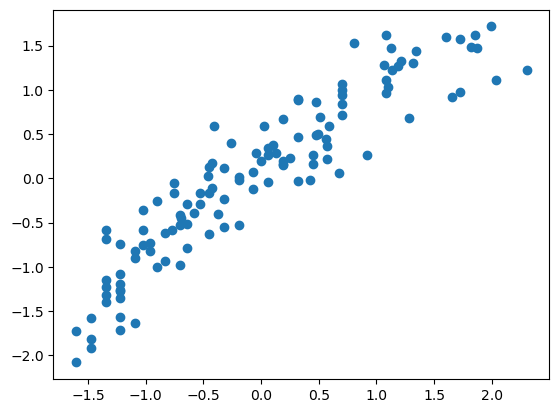

In [22]:
plt.show()